### First example - sinewave perturbation

</b> Author:   </b>  Stefano Merlini     </br>
</b> Reviewer: </b>  

### Import relevant files:

In [9]:
import numpy as np
import matplotlib.pyplot as plt

import sys

#add path
sys.path.insert(0, '../')     # import path/to/sloth
import src.core.config as config
# config.jax_init(force_device = "gpu")

import core.beam as beam_initialiser
import core.domain as d
import core.propagator as p
import processing.diagnostics as diag

import importlib
importlib.reload(beam_initialiser)
importlib.reload(d)
importlib.reload(p)
importlib.reload(diag)

<module 'processing.diagnostics' from '/rds/general/user/sm13118/home/dev/SLOTH/src/processing/diagnostics.py'>

To use the ray tracer, first create a 'domain', load the domain with an electron distribution, calculate electron gradients, initialise a beam, and solve!
\
\
The output can either be plotted, or passed further through ray optics for synthetic diagnostics

In [2]:
# define some extent, the domain should be distributed as +extent to -extent, does not need to be cubic
extent_x = 5e-3
extent_y = 5e-3
extent_z = 10e-3

n_cells = 128

#x = np.linspace(-extent_x, extent_x, n_cells)
#y = np.linspace(-extent_y, extent_y, n_cells)
#z = np.linspace(-extent_z, extent_z, n_cells)

probing_extent = extent_z
probing_direction = 'z'

lengths = 2 * np.array([extent_x, extent_y, extent_z])

#domain = d.ScalarDomain(x = x, y = y, z = z, extent = probing_extent, probing_direction = probing_direction)     # create domain
# Much simpler domain function, no longer needlessly takes in beam values, they are fully seperated
domain = d.ScalarDomain(lengths, n_cells, ne_type = "test_exponential_cos", probing_direction = probing_direction)

# load some external pvti
# import utils.handle_filetypes as load
# ne, dim, spacing = load.pvti_readin(filename)
# or load a test distribution

# only necessary to do so if you are not using the domain initialisation default distribution loading
# - that is the best option if using a test distribution

Predicted size in memory of domain: 8.0 MB

Memory prior to domain creation:
 - total : 24.0 GB
 - free  : 23.2880859375 GB
 - used  : 729.0 MB

Est. domain memory limit: 26.400000000000002 MB
 --> inc. +10.0% variance margin

Coordinates have shape of (128, 128, 128) --> no padding required.

Generating test exponential decay periodic -e field...


Solve gradients, initialise beam, and solve

In [3]:
lwl = 1064e-9 #define laser wavelength

# initialise beam
Np = 2000000    # number of photons
divergence = 5e-5   # realistic divergence value
beam_size = extent_x    # beam radius
ne_extent = probing_extent  # so the beam knows where to initialise initial positions
beam_type = 'circular'

beam_definition = beam_initialiser.Beam(
    Np, beam_size, divergence, ne_extent,
    probing_direction = probing_direction,
    beam_type = "circular"
)

# domain.dim - this causes a TracerBoolConversionError
# passing r_n all individually works though
# also passing ScalarDomain and extracting dim in p.solve(...) causes the same issue
# issue is due to unkown value when assigned to diffrax

rf, _, duration = p.solve(beam_definition.s0, domain, probing_extent)
# defaults: return_E = False, parallelise = True, jitted = True, save_points_per_region = 2, memory_debug = False, lwl = 1064e-9, keep_domain = False, return_raw_results = False


Number of domain batches: 1
Number of ray batches: 1

Est. size in memory of rays (1 = 736 B): 1.3709068298339844 GB
 --> Np = 2000000

No need to generate any sections of the domain, batching not utilised.
 --> tracing a depth of 0.01 mm's to the target depth of 0.01 mm's

Running device: gpu
There are 1 available GPU devices: [CudaDevice(id=0)]

jax compilation of solver took: 0.0004138946533203125 secondsTrue
True
True

Completed ray trace in 5.623 seconds.

Parallelised output has resulting 3D matrix of form: [batch_count, (save_points_per_region - 1) * ScalarDomain.region_count, 6]: (2000000, 2, 6)
 - 2 to account for the start and end results (typical, can be greater if set)
 - 6 containing the 3 position and velocity components
 - If batch_count is lower than expected, this is likely due to jax's forced integer batch sharding requirement over cpu cores.

We slice the results and transpose into the form: (2000000, 2, 6) to work with later code.


Text(0, 0.5, 'e- density')

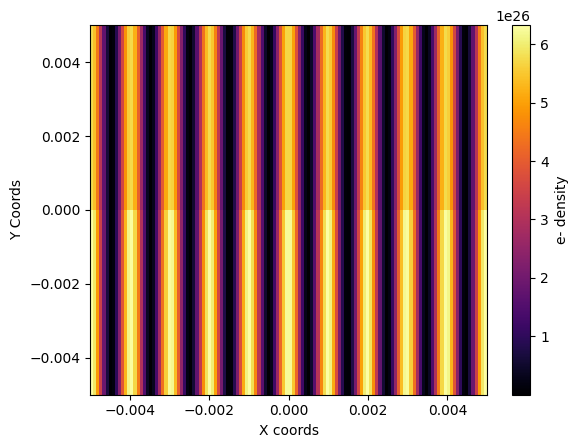

In [4]:
xy = domain.ne[:, :, -1]

heatmap, ax = plt.subplots()

im = ax.imshow([xy[0], xy[1]], cmap='inferno', extent = [domain.x[0], domain.x[-1], domain.y[0], domain.y[-1]], interpolation='nearest', origin = 'lower', aspect = 'auto')
ax.set(xlabel='X coords', ylabel='Y Coords')

cbar = heatmap.colorbar(im)
cbar.ax.set_ylabel('e- density')

25

2000000 rays received, 1267750 incident on the first lens.
 --> 36.600002 % of rays wasted!

rf size expected: [1267750. 1267750.]
rf after clearing nan's: [1267750. 1267750.]


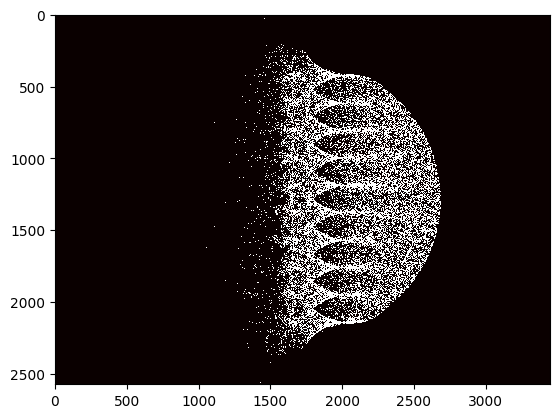

In [16]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = diag.Refractometry(lwl, rf, R = 25)
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.plot_rays(bin_scale = 1, clear_mem = False)

#information accessed by .H(istogram) , e.g plt.imshow(refractometer.H)

#plt.imshow(refractometer.H, cmap='hot', interpolation='nearest', clim = (0, 2))
plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))

25

2000000 rays received, 1267750 incident on the first lens.
 --> 36.600002 % of rays wasted!


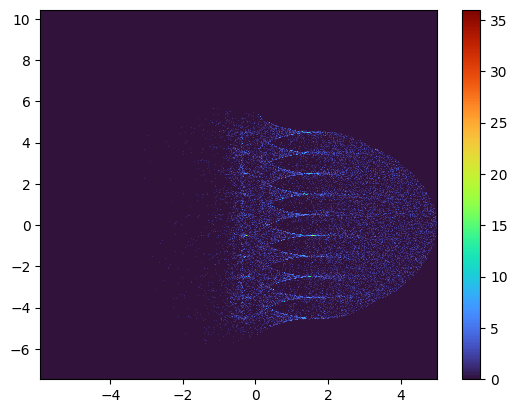

In [20]:
#from diagnostics import m_to_mm
#rf_mm = m_to_mm(rf)

# this will both convert to mm and avoid unnecessary rays
converter = diag.Refractometry(lwl, rf)
rf_mm = converter.r0
del converter

from shared.utils import heat_plot
heat_plot(rf_mm[0], rf_mm[2])

Pass through ray optics: For Shadowgaphy, Schlieren, or Refractometry:


2000000 rays received, 1267294 incident on the first lens.
 --> 36.600002 % of rays wasted!

rf size expected: [1267294. 1267294.]
rf after clearing nan's: [1267290. 1267290.]


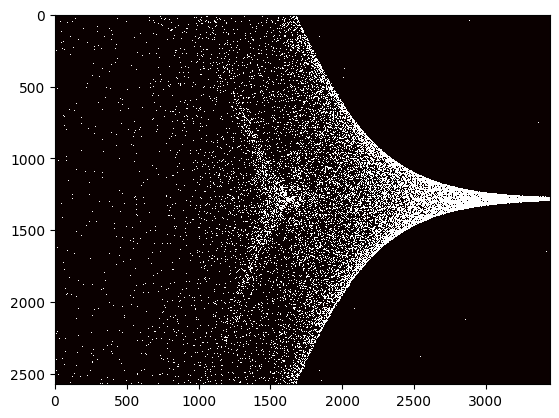

In [7]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = diag.Refractometry(lwl, rf)
refractometer.incoherent_solve()
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.histogram(bin_scale = 1, clear_mem = False)

#information accessed by .H(istogram) , e.g plt.imshow(refractometer.H)

#plt.imshow(refractometer.H, cmap='hot', interpolation='nearest', clim = (0, 2))
plt.imshow(refractometer.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


2000000 rays received, 1267294 incident on the first lens.
 --> 36.600002 % of rays wasted!

rf size expected: [1267294. 1267294.]
rf after clearing nan's: [1267292. 1267292.]


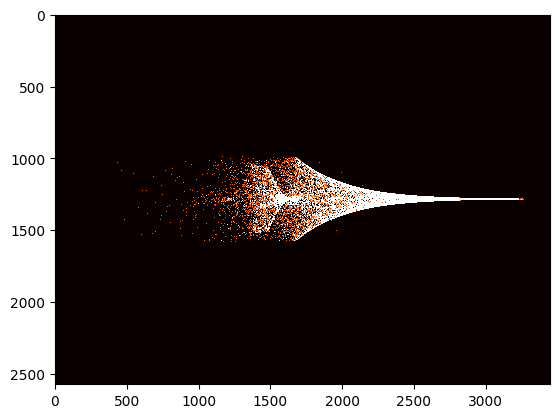

In [13]:
#in the diagnostic initialisation, details on the lens configurations, and detector dimensions can be specified
refractometer = diag.Refractometry(lwl, rf, L = 50)
refractometer.incoherent_solve()
# cam't clear_mem if you want to generate other graphs afterwards
refractometer.histogram(bin_scale = 1, clear_mem = False)

#information accessed by .H(istogram) , e.g plt.imshow(refractometer.H)

plt.imshow(refractometer.H, cmap='hot', interpolation='nearest', clim = (0, 2))


2000000 rays received, 1267294 incident on the first lens.
 --> 36.600002 % of rays wasted!

rf size expected: [1267294. 1267294.]
rf after clearing nan's: [1267292. 1267292.]


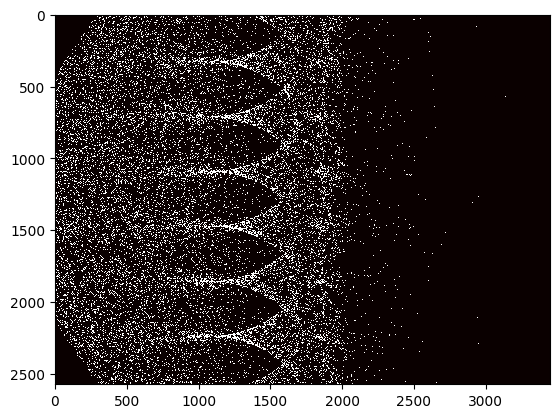

In [14]:
shadowgrapher = diag.Shadowgraphy(lwl, rf)
shadowgrapher.single_lens_solve()
shadowgrapher.histogram(bin_scale = 1, clear_mem = False)

plt.imshow(shadowgrapher.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))


2000000 rays received, 1266103 incident on the first lens.
 --> 36.7 % of rays wasted!

rf size expected: [1266103. 1266103.]
rf after clearing nan's: [757455. 757455.]


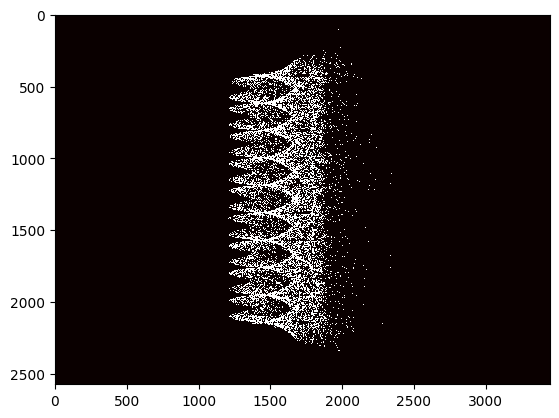

In [10]:
schlierener = diag.Schlieren(lwl, rf)
schlierener.DF_solve()
schlierener.histogram(bin_scale = 1, clear_mem = True)

plt.imshow(schlierener.H, cmap = 'hot', interpolation = 'nearest', clim = (0.5, 1))